In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/motor_training_data.csv')

In [4]:
df.head()

,Timestamp,RMS_X,Peak_Freq_X,Max_Magnitude_X,Condition_Label
0,2026-07-22 11:07:25,0.3991,117.19,13.4871,HEALTHY
1,2026-07-22 11:07:25,0.3977,117.19,11.9492,HEALTHY
2,2026-07-22 11:07:25,0.4005,115.62,13.1053,HEALTHY
3,2026-07-22 11:07:25,0.4021,57.81,10.7313,HEALTHY
4,2026-07-22 11:07:26,0.4017,117.19,10.7255,HEALTHY


In [17]:
#delete the first 1000 rows as the data aren't correct
df1 =df.drop(df.index[0:1059])

In [16]:
df1[:20]

,Timestamp,RMS_X,Peak_Freq_X,Max_Magnitude_X,Condition_Label
1057,2026-07-22 11:22:50,0.4022,106.25,7.3844,HEALTHY
1058,2026-07-22 11:22:50,0.4009,106.25,7.4590,HEALTHY
1059,2026-07-22 18:12:16,0.4172,59.38,57.7429,INBALANCE
1060,2026-07-22 18:12:17,0.4172,59.38,59.2039,INBALANCE
1061,2026-07-22 18:12:18,0.4151,59.38,61.1676,INBALANCE
1062,2026-07-22 18:12:19,0.4151,59.38,60.5795,INBALANCE
1063,2026-07-22 18:12:19,0.4132,59.38,59.0869,INBALANCE
1064,2026-07-22 18:12:20,0.4157,59.38,60.9418,INBALANCE
1065,2026-07-22 18:12:21,0.4144,59.38,59.0210,INBALANCE
1066,2026-07-22 18:12:22,0.4143,59.38,58.9025,INBALANCE


In [21]:
df1['Condition_Label'].value_counts()

,count
Condition_Label,
LOOSE MOUNTING,1020
HEALTHY,1001
INBALANCE,964


In [66]:
# Add new column to represent each condition labe, 0- HEALTHY, 1 - INBALANCE, 2 - LOOSE MOUNTING
df1.loc[df1['Condition_Label'] == 'HEALTHY', 'Condition_Label'] = 0
df1.loc[df1['Condition_Label'] == 'INBALANCE', 'Condition_Label'] = 1
df1.loc[df1['Condition_Label'] == 'LOOSE MOUNTING', 'Condition_Label'] = 2

# Convert the Condition_Label column to integer type
df1['Condition_Label'] = df1['Condition_Label'].astype(int)

In [74]:
df1['RMS_X'].astype(float)
df1['Max_Magnitude_X'].astype(float)
df1['Peak_Freq_X'].astype(float)

,Peak_Freq_X
1059,59.38
1060,59.38
1061,59.38
1062,59.38
1063,59.38
...,...
4039,60.94
4040,60.94
4041,60.94
4042,60.94


In [75]:
#Checking the collumns type
df1.dtypes

,0
Timestamp,object
RMS_X,float64
Peak_Freq_X,float64
Max_Magnitude_X,float64
Condition_Label,int64


In [76]:
df1.columns

Index(['Timestamp', 'RMS_X', 'Peak_Freq_X', 'Max_Magnitude_X',
       'Condition_Label'],
      dtype='object')

In [77]:
df1.head()

,Timestamp,RMS_X,Peak_Freq_X,Max_Magnitude_X,Condition_Label
1059,2026-07-22 18:12:16,0.4172,59.38,57.7429,1
1060,2026-07-22 18:12:17,0.4172,59.38,59.2039,1
1061,2026-07-22 18:12:18,0.4151,59.38,61.1676,1
1062,2026-07-22 18:12:19,0.4151,59.38,60.5795,1
1063,2026-07-22 18:12:19,0.4132,59.38,59.0869,1


In [78]:
# Check for any missing value
df1.isnull().sum()

,0
Timestamp,0
RMS_X,0
Peak_Freq_X,0
Max_Magnitude_X,0
Condition_Label,0


ANALYSIS OF THE DATASET

In [33]:
import matplotlib.pyplot as plt

In [79]:
# 2. Summary Statistics by Class
# This shows us the average RMS, Frequency, and Magnitude for each physical state
print("\n--- Mean Values by Condition ---")
display(df.groupby('Condition_Label')[['RMS_X', 'Peak_Freq_X', 'Max_Magnitude_X']].mean())


--- Mean Values by Condition ---


,RMS_X,Peak_Freq_X,Max_Magnitude_X
Condition_Label,,,
HEALTHY,0.419216,95.684252,9.094559
INBALANCE,0.495746,68.163434,80.494237
LOOSE MOUNTING,0.799785,70.065304,192.263054


In [81]:
import seaborn as sns

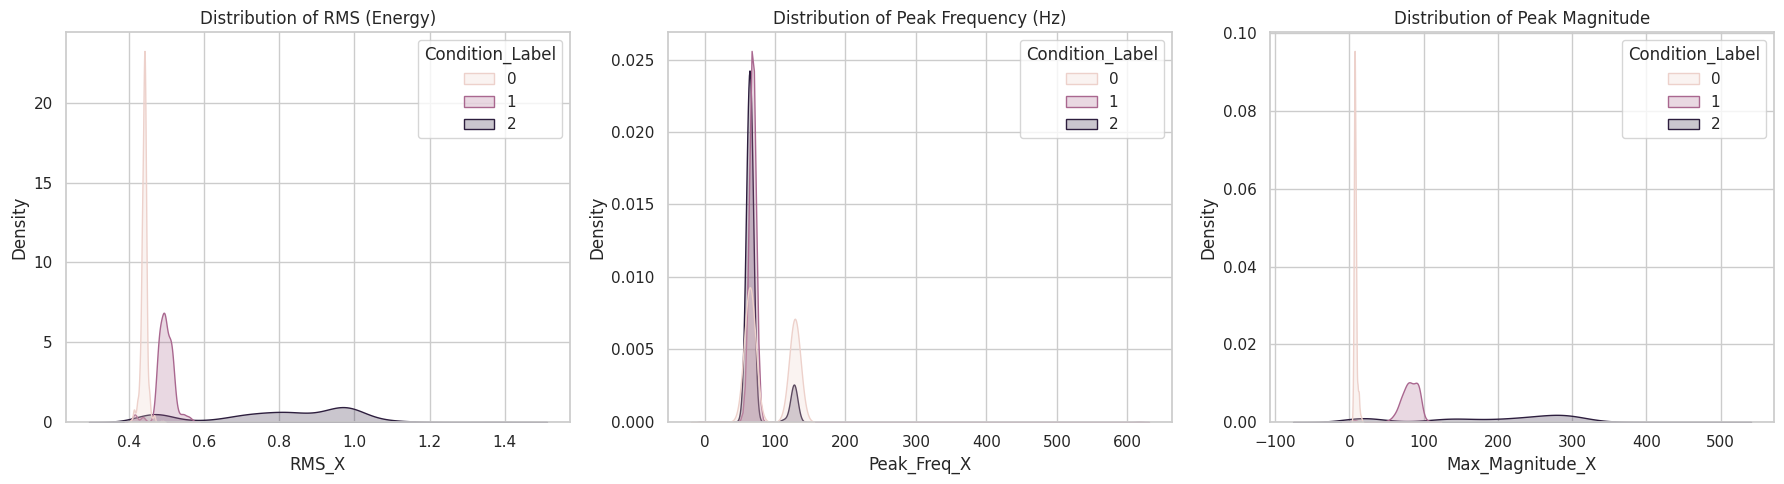

In [82]:


# Set up the visual style
sns.set_theme(style="whitegrid")

# 3. Feature Distributions (KDE Plots)
# These density plots show how well the classes separate on each individual feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(data=df1, x='RMS_X', hue='Condition_Label', fill=True, ax=axes[0])
axes[0].set_title('Distribution of RMS (Energy)')

sns.kdeplot(data=df1, x='Peak_Freq_X', hue='Condition_Label', fill=True, ax=axes[1])
axes[1].set_title('Distribution of Peak Frequency (Hz)')

sns.kdeplot(data=df1, x='Max_Magnitude_X', hue='Condition_Label', fill=True, ax=axes[2])
axes[2].set_title('Distribution of Peak Magnitude')

plt.tight_layout()
plt.show()

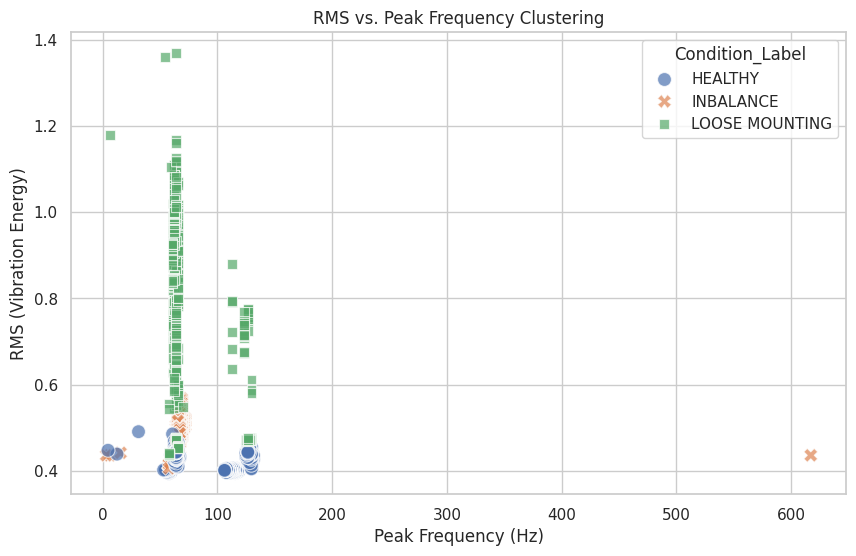

In [83]:
# 4. 2D Scatter Plot (RMS vs. Peak Frequency)
# This will show us the actual physical clusters. The Random Forest draws boundaries around these.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Peak_Freq_X', y='RMS_X', hue='Condition_Label', style='Condition_Label', s=100, alpha=0.7)
plt.title('RMS vs. Peak Frequency Clustering')
plt.xlabel('Peak Frequency (Hz)')
plt.ylabel('RMS (Vibration Energy)')
plt.show()



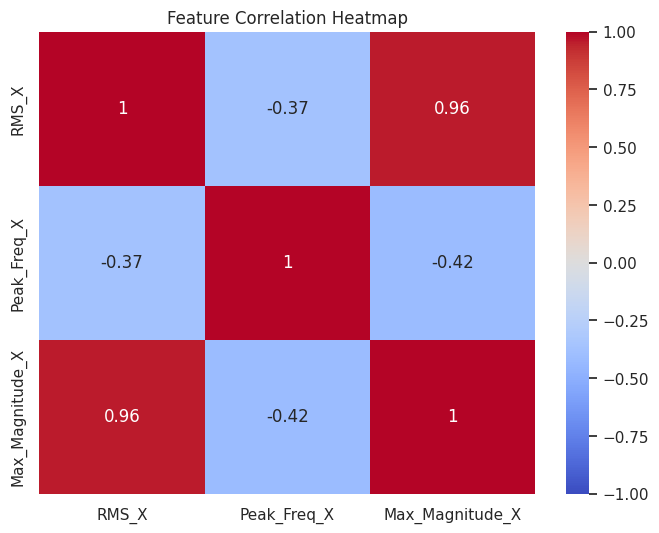

In [84]:
# 5. Correlation Heatmap
# Let's see if any features are perfectly correlated (redundant)
plt.figure(figsize=(8, 6))
correlation_matrix = df[['RMS_X', 'Peak_Freq_X', 'Max_Magnitude_X']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

In [85]:
# 2. Separate Features (X) and Labels (y)
# Drop Timestamp as it's not a physical feature
X = df1[['RMS_X', 'Peak_Freq_X', 'Max_Magnitude_X']]
y = df1['Condition_Label']

In [86]:
# 3. Train/Test Split (70% training, 30% testing as per your document)
# Using stratify=y ensures all three classes are evenly represented in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

In [87]:
#Scaling the Dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
X_train.count()

AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [89]:
X_test.count()

AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [90]:
X_train[0:50]


array([[ 1.31362128, -0.58101759,  1.62375277],
       [-0.55952512,  2.0727863 , -0.77584605],
       [-0.46366349, -0.38672568, -0.29982514],
       [-0.39599646, -0.25747391,  0.04018906],
       [-0.56157563, -0.51639171, -0.79449438],
       [-0.74150841,  2.20245233, -0.89515917],
       [-0.50211067, -0.38672568, -0.14155725],
       [-0.45904983, -0.38672568, -0.13712609],
       [ 0.95990727,  2.0727863 ,  0.48665967],
       [ 1.02501115, -0.51639171,  1.20257008],
       [-0.4513604 , -0.32209979, -0.03447178],
       [-0.43495627, -0.38672568, -0.20125319],
       [-0.49544649, -0.38672568, -0.17427136],
       [-0.70203598, -0.51639171, -0.8548194 ],
       [-0.72151588, -0.51639171, -0.88197615],
       [-0.68973288,  2.0727863 , -0.89147983],
       [-0.74509682, -0.45176583, -0.86805459],
       [-0.42829209, -0.38672568, -0.28034827],
       [-0.73535687,  2.0727863 , -0.90291166],
       [-0.73381898, -0.45176583, -0.87534372],
       [-0.41701425, -0.51639171, -0.219

In [54]:
y_train[0:50]

,Condition_Label
3924,2
3143,2
1675,1
1102,1
3148,2
2261,0
1742,1
1655,1
3250,2
3766,2


In [91]:
# 4. Initialize and Train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [96]:



# 5. Evaluate the Model
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Imbalance', 'Loose Mounting']))



Accuracy: 99.67%

Classification Report:
                precision    recall  f1-score   support

       Healthy       0.99      1.00      1.00       301
     Imbalance       1.00      0.99      0.99       289
Loose Mounting       1.00      1.00      1.00       306

      accuracy                           1.00       896
     macro avg       1.00      1.00      1.00       896
  weighted avg       1.00      1.00      1.00       896



In [97]:
# 6. Export the Model for the Web Dashboard
joblib.dump(rf_model, '/content/drive/MyDrive/Colab Notebooks/random_forest_motor_model.pkl')
print("Model saved successfully for deployment!")

Model saved successfully for deployment!


In [ ]:
# confussion Matrix
from sklearn.metrics import confusion_matrix

# Confussion matrix between


